In [4]:
%reset -f 

from LadrunoGraphStyle import set_default_plot_params, main_colors
set_default_plot_params()

In [5]:
from ShakerMakerResults import ShakerMakerData

import numpy as np
import os

import h5py
import matplotlib.pyplot as plt

## Surface STG SW4

In [6]:

# folder = r'C:\Dropbox\resources\STG_Surface'


folder= '/home/pxpalacios/Dropbox/01. Brain/11. GitHub/ShakerMakerResults/examples/Compare_sw4_shaker'

folder = r'C:\Dropbox\01. Brain\11. GitHub\ShakerMakerResults\examples\Compare_sw4_shaker'
h5drm = os.path.join(folder, 'ffsp_source.h5drm')

STG_surface = ShakerMakerData(h5drm)


  vmax cache loaded from sidecar.
----------------------------------------------------------------------------------------------------
ShakerMakerData  :  C:\Dropbox\01. Brain\11. GitHub\ShakerMakerResults\examples\Compare_sw4_shaker\ffsp_source.h5drm
  Type     : SurfaceGrid
  Model    : ffsp_source  |  Spacing: 250.0m x 250.0m x 0.0m
  Domain   : Lx=30000.0m  Ly=30000.0m  Lz=0.0m
  Nodes    : 14641  |  Internal: 0  |  External: 14641
  QA       : yes  ->  [6293815.47973042  349518.53893047       0.        ] m
  Time     : dt=0.007222302000000001s  |  steps=5001  |  t=[0.000, 36.119]s
  GF       : steps=0  |  not loaded
  Version  : ShakerMaker  |  2026-05-10T17:52:08.070605
  RAM      : 16.9 GB used  |  16.6 GB free  |  50.6%
  File size:
    acceleration         (43923, 5001)  1.76 GB
    displacement         (43923, 5001)  1.76 GB
    velocity             (43923, 5001)  1.76 GB
    xyz                  (14641, 3)  0.00 GB
    TOTAL                             5.27 GB
--------------

----------------------------------------------------------------------------------------------------
Resample
  Data dt  : 0.007222s -> 0.010000s
  Data     : 5001 -> 3612 samples
  Time     : [0.000, 36.112] s unchanged
  GF       : not loaded
----------------------------------------------------------------------------------------------------

--------------------------------------------------
NODE INFO
  QA       │ pos = [6293815.48,  349518.54,       0.00] m
--------------------------------------------------


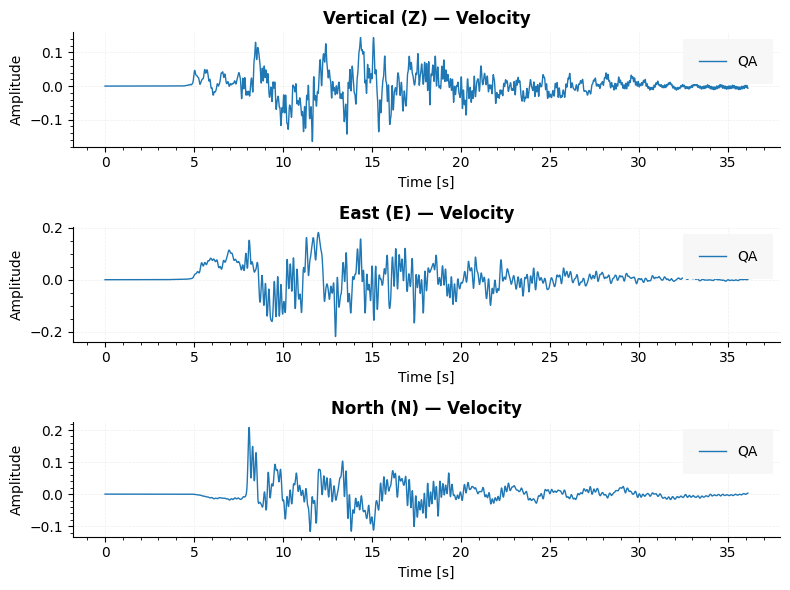

In [7]:
# resample 
STG_surface_resample = STG_surface.resample(dt=0.01)
STG_surface_resample.plot_node_response(
                                node_id='QA', 
                                data_type='vel', 
                                figsize=(8, 6),
                                factor=1.0,
                                )

----------------------------------------------------------------------------------------------------
Window   : ffsp_source
  Range  : [0.000, 30.000] s
  Data   : 5001 -> 4154 samples
  Time   : [0.000, 36.112] -> [0.000, 29.994] s
----------------------------------------------------------------------------------------------------

--------------------------------------------------
NODE INFO
  N7320   │ pos = [6293815.48,  349518.54,       0.00] m │ external  ★ COINCIDES WITH QA
  Target   │ pos = [6293815.48,  349518.54,       0.00] m │ dist = 0.00 m
--------------------------------------------------


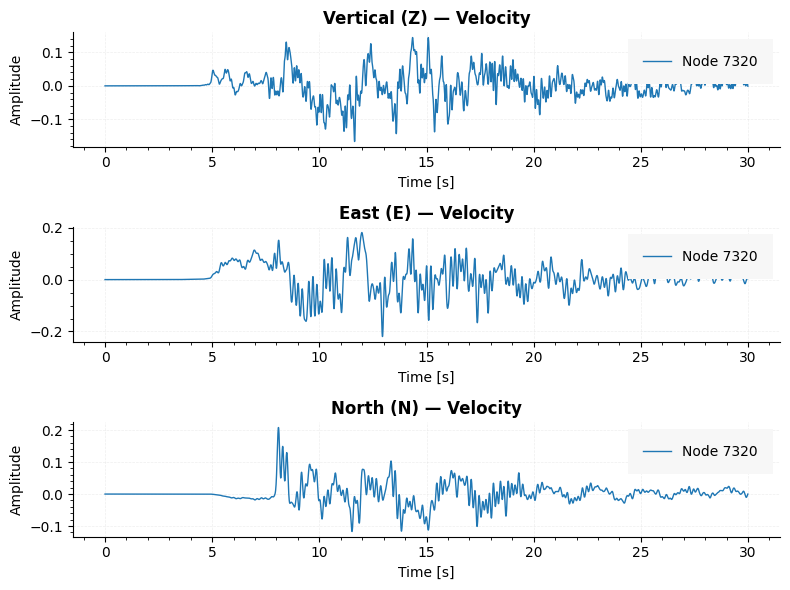

In [8]:
# get_window

STG_surface_window= STG_surface.get_window(t_start=0.0, t_end=30.0)

STG_surface_window.plot_node_response(
                                target_pos=[6293815.48/1e3,  349518.54/1e3,       0.00],
                                data_type='vel', 
                                figsize=(8, 6),
                                factor=1.0,
                                )

In [9]:
STG_surface_window.viewer()

[DEBUG] LeftButtonPressEvent
[DEBUG]   pos=(163,490)
[DEBUG]   ctrl=False
[DEBUG] LeftButtonReleaseEvent
[DEBUG]   pos=(163,490) dragging=False
[DEBUG]   pick point_id=-1
[DEBUG] LeftButtonPressEvent
[DEBUG]   pos=(433,511)
[DEBUG]   ctrl=False
[DEBUG] LeftButtonReleaseEvent
[DEBUG]   pos=(433,511) dragging=False
[DEBUG]   pick point_id=12605
[DEBUG]   -> on_point_picked callback
[DEBUG] KeyPressEvent: key='control_l'
[DEBUG] LeftButtonPressEvent
[DEBUG]   pos=(639,313)
[DEBUG]   ctrl=True
[DEBUG] LeftButtonReleaseEvent
[DEBUG]   pos=(639,313) dragging=False
[DEBUG]   pick point_id=6487
[DEBUG]   -> on_point_picked callback
[DEBUG] LeftButtonPressEvent
[DEBUG]   pos=(443,268)
[DEBUG]   ctrl=True
[DEBUG] LeftButtonReleaseEvent
[DEBUG]   pos=(443,268) dragging=False
[DEBUG]   pick point_id=4984
[DEBUG]   -> on_point_picked callback
[DEBUG] LeftButtonPressEvent
[DEBUG]   pos=(715,478)
[DEBUG]   ctrl=True
[DEBUG] LeftButtonReleaseEvent
[DEBUG]   pos=(715,478) dragging=False
[DEBUG]   pick 

In [10]:
ppp

NameError: name 'ppp' is not defined

In [ ]:
STG_surface_window.plot_domain( 
    xyz_origin=None,
    label_nodes='corners',
    show_calculated=False,
    figsize=(8, 6),
    axis_equal=True,
)

In [ ]:
# Por ID
STG_surface_window.plot_node_newmark( 
                        node_id=['QA' , 0,10000], 
                        data_type='accel', 
                        spectral_type='PSa',
                        figsize=(8, 6),
                        factor=1/9.81,
                        )

In [ ]:
STG_surface_window.plot_node_arias(              
                    node_id=['QA' , 0,1000],
                    data_type     = 'accel',
                    figsize=(8, 6),
                    factor=1,
                    )

In [ ]:
# Plot surface snapshot
STG_surface_window.plot_surface(  time=10.0, 
                            component='resultant', 
                            data_type='vel', 
                            cmap='RdBu_r', 
                            figsize=(8, 8),
                            elev=30, azim=-60, s=20, alpha=0.9,
                            axis_equal=True,)
    

In [ ]:
# STG_surface_window.plot_surface_newmark(
#                         T_target      = 0.0,
#                         component     = 'resultant',
#                         data_type     = 'accel',
#                         spectral_type = 'PSa',
#                         factor        = 1.0/9.81,
#                         cmap          = 'viridis',
#                         figsize       = (8, 6),
#                         # elev          = 35,
#                         # azim          = -60,
#                         s             = 20,
#                         alpha         = 0.85,
#                         axis_equal    = True,
#                         n_jobs        = -2,
# )

In [ ]:
# STG_surface_window.plot_surface_arias(
#                     component  = 'z',
#                     data_type  = 'accel',
#                     factor     = 1.0,
#                     cmap       = 'turbo',
#                     figsize       = (8, 6),
#                     elev          = 35,
#                     azim          = -60,
#                     s          = 20,
#                     alpha      = 0.85,
#                     axis_equal = True,
#                     n_jobs     = -2,
# )

In [ ]:
# STG_surface_window.viewer()

## Shaker

In [ ]:

folder = '/home/pxpalacios/Dropbox/resources/STG_Surface'
# folder= '/home/pxpalacios/Desktop/STG_Surface'

# folder= '/home/pxpalacios/Desktop/New_folder'

h5drm = os.path.join(folder, 'STG_Surface.h5drm')
h5gf  = os.path.join(folder, 'STG_Surface_gf.h5')
h5map  = os.path.join(folder, 'STG_Surface_map.h5')


STG_surface_Shaker = ShakerMakerData(h5drm)
# STG_surface.load_gf_database(h5gf)
# STG_surface.load_map(h5map)


In [ ]:
# resample 
STG_surface_shakermaker_resample = STG_surface_Shaker.resample(dt=0.01)
STG_surface_shakermaker_resample.plot_node_response(
                                node_id='QA', 
                                data_type='vel', 
                                figsize=(8, 6),
                                factor=1.0,
                                )

In [ ]:
# get_window

STG_surface_shaker_window= STG_surface_Shaker.get_window(t_start=0.0, t_end=30.0)

STG_surface_shaker_window.plot_node_response(
                                target_pos=[6293815.48/1e3,  349518.54/1e3,       0.00],
                                data_type='vel', 
                                figsize=(8, 6),
                                factor=1.0,
                                )

In [ ]:
# Por ID
STG_surface_shaker_window.plot_node_newmark( 
                        node_id=['QA' , 0,1000], 
                        data_type='accel', 
                        spectral_type='PSa',
                        figsize=(8, 6),
                        factor=1/9.81,
                        )

In [ ]:
STG_surface_shaker_window.plot_node_arias(              
                    node_id=['QA' , 0,1000],
                    data_type     = 'accel',
                    figsize=(8, 6),
                    factor=1,
                    )

In [ ]:
STG_surface_shaker_window.model_name='STG_surface_shaker_window'

STG_surface_window.model_name='STG_surface_window'

## comapre

In [ ]:
from ShakerMakerResults import (
    plot_models_response,
    plot_models_newmark,
    plot_models_gf,
    plot_models_tensor_gf,
    plot_models_domain,
    plot_models_arias,
    compare_node_response,
    compare_spectra,
)

In [ ]:
plot_models_response(
    models=[STG_surface_window, STG_surface_shaker_window],
    node_ids=[['QA'], ['QA']],
    target_pos=None,
    data_type="vel",
    xlim=None,
    figsize=(10, 8),
    factor=1.0,
)

In [ ]:
plot_models_newmark(
    models=[STG_surface_window, STG_surface_shaker_window],
    node_ids=[['QA'], ['QA']],
    target_pos=None,
    data_type="accel",
    spectral_type="PSa",
    xlim=None,
    figsize=(8, 10),
    factor=1.0,
)